# Random Forest and XGBoost Models Script

## This script accomplishes the following:

In this script, we will run 2 models, to predict the number of conflicts in each ZIP code, in each month.
The predictions are generated in a traditional ML way. We split the data into train and test sets, train the random forest on the former and  make the predicictions on the later.
Hence, we mask data that we "already saw", and then evaluate the models performance by taking the deviation from our predictions to the actual data.

In this script, we **predict**, we don't **forecast**, as the data is present and has already taken place, hence giving us a way to actually evaluate the model.

## Find the following steps below:

1. **Random Forest Model**

- Define features and label (number of conflicts, for each ZIP in PA, for each month)
- Perform 5-fold time-series-cross-validation
- Split the data 70/30 train and test
- Normalize the sets
- Define the rf regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

2. **XGBoost Model**

- Define the xgb regressor and fit
- Perform feature importance analysis
- Run a Grid Search to find the optimal parameter values
- Re-fit the model
- Make predictions
- Evaluation of Predictions

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from joblib import dump, load


In [2]:
#Dynamic search path configuration
import sys
import os

#Adjusting search path based on notebook's depth in directory --> iterates through directories until it finds directory name: US_conflict_forecasting
current_dir = os.getcwd()
while 'US_conflict_forecasting' not in os.path.basename(current_dir):
    current_dir = os.path.dirname(current_dir)

#Adjusting search path based on 'new' current directory
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

from project_setup import setup_project
project_root_dir = setup_project()

import pandas as pd

Current Project Root Directory set to: /Users/danie/Desktop/Hertie/2. Semester/1. ML/0. Final Project/US_conflict_forecasting
Current Search Path set to: ['c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting', 'c:\\Users\\danie\\Desktop\\Hertie\\2. Semester\\1. ML\\0. Final Project\\US_conflict_forecasting\\3_Models', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\danie\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32\\lib', 'C:\\Users\\danie\\AppData\\Roaming\\Python\\Python312\\site-packages\\Pythonwin', 'c:\\Users\\danie\\AppData\

### Load the data

In [3]:
# Load the data

data = pd.read_csv(os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset/Final_Dataset_Lag_clean.csv'))


## 1. Random Forest

### Features and labels, cross-validation, split and normalization

In [4]:
train = data[data['month'] <= 9]

test = data[data['month'] > 9]

In [5]:
X_train = train.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_train = train['event_count']


X_test = test.drop(['event_count', 'ZCTA', 'month'], axis=1)
Y_test = test['event_count']

In [6]:
# Time Series Cross Validation, 5 folds.

tscv = TimeSeriesSplit(n_splits=5)

In [7]:
'''
# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
'''

### Define the regressor and run

In [7]:
rf_regressor = RandomForestRegressor(n_estimators = 100, random_state = 100)

In [8]:
rf_regressor.fit(X_train, Y_train)

RandomForestRegressor(random_state=100)

### Feature importance

In [9]:
# Which are the most important features?

feature_importances = rf_regressor.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]

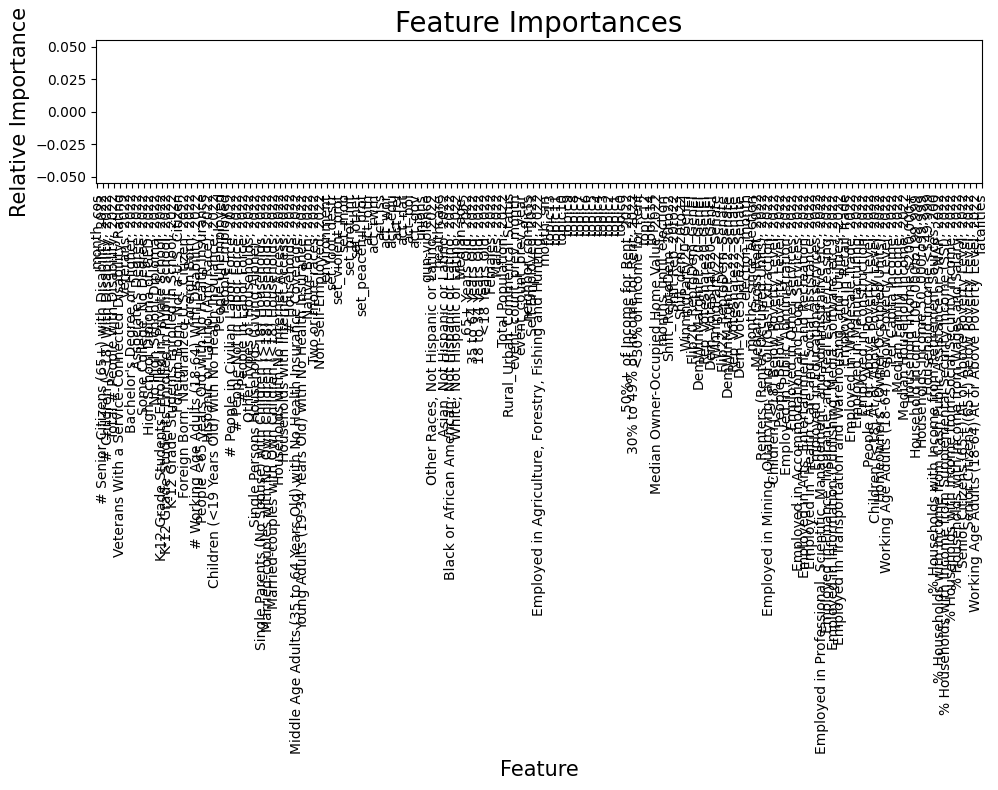

In [10]:
# Assuming rf is your trained RandomForestClassifier
feature_importances = rf_regressor.feature_importances_

# Adjusting feature_names to match your processed 'carseats' DataFrame
# Ensure this line comes after all preprocessing steps, including get_dummies and drop
feature_names = X_train.columns

# Sort the feature importances in descending order and get their indices
sorted_indices = np.argsort(feature_importances)[::-1]

# Create the plot
plt.figure(figsize=(10, 8))
plt.title('Feature Importances', fontsize=20)
plt.bar(range(len(feature_importances)), feature_importances[sorted_indices], align='center', alpha=0.5)
plt.xticks(range(len(feature_importances)), feature_names[sorted_indices], rotation=90)
plt.ylabel('Relative Importance', fontsize=15)
plt.xlabel('Feature', fontsize=15)
plt.tight_layout()  # Adjusts the plot to ensure everything fits without overlapping
plt.show()

In [11]:
# Print the 10 most important features

for i in range(20):
    print(f'{feature_names[sorted_indices[i]]}: {feature_importances[sorted_indices[i]]}')

month_cos: nan
# Senior Citizens (65+) with Disability, 2022: nan
# Children (<18) With Disability, 2022: nan
Total # People with Disability, 2022: nan
Veterans With a Service-Connected Disability Rating: nan
Veterans, 2022: nan
Bachelor's Degree or Higher, 2022: nan
Associate's Degree, 2022: nan
Some College, No Degree, 2022: nan
High School Diploma or GED, 2022: nan
No High School Diploma, 2022: nan
K-12 Grade Students Enrolled in Private School, 2022: nan
K-12 Grade Students Enrolled in Public School, 2022: nan
K-12 Grade Students Enrolled in School, 2022: nan
Foreign Born, Not a U.S. Citizen: nan
Foreign Born, Naturalized U.S. Citizen, 2022: nan
Foreign Born, 2022: nan
# Working Age Adults (18-64) With Disability, 2022: nan
People <65 years Old with No Health Insurance: nan
Hispanic or Latino (Any Race), 2022: nan


### Run Grid Search to find the best parameters

In [80]:
# Grid Search for best parameters

# Adjust number of trees in forest, max depth of trees, and minimum samples per leaf

# n_estimators: Number of trees in the forest, to take into account for the prediction
# max_depth: Maximum depth of the tree. From root to leaf, basically controls complexity of the tree and can lead/prevent overfitting. The more splits, the more complex the tree and the more likely to fit noise.
# min_samples_split: Minimum number of samples required to split an internal node


# Prevents overfitting and improves the generalization of the model

param_grid = {
    'n_estimators': [20, 30, 40],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [81]:
cv_rf = GridSearchCV(estimator=rf_regressor, param_grid=param_grid, cv = tscv, n_jobs=-1)
cv_rf.fit(X_train_scaled, Y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=100), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 50],
                         'min_samples_split': [2, 5, 7, 8],
                         'n_estimators': [100, 300, 500]})

## Run the predictions

### Without Best Parameters

In [82]:
Y_pred = rf_regressor.predict(X_test_scaled)

predictions = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred})
print(Y_pred)

[0. 0. 0. ... 0. 0. 0.]


In [83]:
mse = mean_squared_error(Y_test, Y_pred)

print('Mean Squared Error:', mse)

Mean Squared Error: 0.08512684124386252


### Including the Best Parameters

In [84]:
Y_pred_gs = cv_rf.predict(X_test_scaled)

predictions_gs = pd.DataFrame({'Actual': Y_test, 'Predicted': Y_pred_gs})
print(Y_pred_gs)

[0. 0. 0. ... 0. 0. 0.]


In [85]:
mse_gs = mean_squared_error(Y_test, Y_pred_gs)

print('Mean Squared Error:', mse_gs)

Mean Squared Error: 0.08512684124386252


### Show predictions and model evaluations

In [76]:
ZIP_results = pd.merge(predictions_gs, data[['ZCTA', 'month']], left_index=True, right_index=True)

In [77]:
print(ZIP_results)

       Actual  Predicted     ZCTA  month
9         0.0        0.0  15001.0   10.0
10        0.0        0.0  15001.0   11.0
11        0.0        0.0  15001.0   12.0
21        0.0        0.0  15003.0   10.0
22        0.0        0.0  15003.0   11.0
...       ...        ...      ...    ...
21982     0.0        0.0  19610.0   11.0
21983     0.0        0.0  19610.0   12.0
21993     0.0        0.0  19611.0   10.0
21994     0.0        0.0  19611.0   11.0
21995     0.0        0.0  19611.0   12.0

[5499 rows x 4 columns]


In [51]:
ZIP_results_conflict = ZIP_results[ZIP_results['Predicted'] > 0]


In [46]:
mse = mean_squared_error(Y_test, Y_pred_gs)

print('Mean Squared Error:', mse)

Mean Squared Error: 0.10178941625750139


In [ ]:


output_directory_1 = os.path.join(project_root_dir, '2_Dataset/d_Final_Dataset')
dump(cv_rf, '/path/to/your/directory/rf_model.joblib')


In [96]:
output_directory_1 = os.path.join(project_root_dir, '3_Models')
output_filename_1 = "rf_lag.csv"
output_path_1 = os.path.join(output_directory_1, output_filename_1)

dump(cv_rf, output_path_1)


['/Users/danie/Desktop/Hertie/2. Semester/1. ML/0. Final Project/US_conflict_forecasting\\3_Models\\rf_lag.csv']